## 1. Data Preprocessing

We start by preparing our working environment. This involves loading the data and performing a strategic selection of features. Since the original dataset contains 195 columns, we need to focus on the variables that directly help us understand the matching process (demographics, expectations, and actual ratings).

In [50]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



In [51]:
# Load dataset
df = pd.read_csv("../data/Speed+Dating+Data.csv", encoding='ISO-8859-1')
#ISO-8859-1')



In [52]:
# Display the first 5 rows to verify
df.head(100)

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10,10.0,0,19,1,1,10,2,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,10,10.0,0,19,1,1,10,2,NaN,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,10,10.0,0,19,1,1,10,2,NaN,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,10,10.0,0,19,1,1,10,2,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Display dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


In [54]:
df.describe()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Before we start analyzing, we need to check if all the data is actually usable. Many columns in this dataset were collected months after the experiment ended, or simply contain too many missing answers.

We are going to visualize the "gaps" (missing values) in the data to see which columns are not reliable.

In [55]:
# Calculating the percentage of missing values for each column
missing_values = df.isnull().sum() / len(df) * 100
missing_values = missing_values.sort_values(ascending=False)

C:\Users\semia\AppData\Local\Temp\ipykernel_37680\1163337362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index[:30], y=missing_values.values[:30], palette="flare")


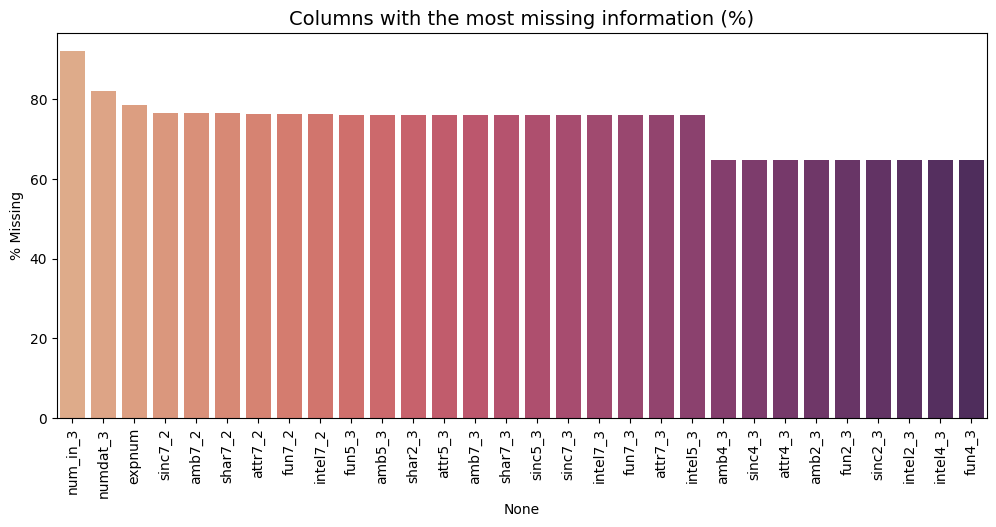

In [56]:
# Plotting the top 30 columns with most missing data
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_values.index[:30], y=missing_values.values[:30], palette="flare")
plt.title("Columns with the most missing information (%)", fontsize=14)
plt.ylabel("% Missing")
plt.xticks(rotation=90)
plt.show()


In [57]:
# Counting how many columns have more than 30% missing data
too_many_nans = missing_values[missing_values > 30].count()
print(f"There are {too_many_nans} columns with more than 30% missing data.")

There are 83 columns with more than 30% missing data.


As we can see, dozens of columns are almost empty (up to 90% missing values). Also, many other columns are about long-term surveys that don't help us understand the initial "spark" between two people.

To stay focused and accurate, we have selected only 20 key columns. These columns represent the heart of the experiment:

Who are the participants? (Age, Gender, Race)

What do they expect? (Initial preferences)

What actually happened? (Scores given during the date and the final decision)

In [58]:
# Strategic selection of features
selected_columns = [
    'iid', 'gender', 'age', 'race', 'order', 'match', 'int_corr', 'samerace',
    'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', # Expectations
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', # Real ratings received
    'attr3_1', 'dec', 'like'
]

df_reduced = df[selected_columns].copy()
print(f"Data reduced to {df_reduced.shape[1]} columns.")

Data reduced to 23 columns.


In [59]:
df_reduced.head()

,iid,gender,age,race,order,match,int_corr,samerace,attr1_1,sinc1_1,...,shar1_1,attr,sinc,intel,fun,amb,shar,attr3_1,dec,like
0,1,0,21.0,4.0,4,0,0.14,0,15.0,20.0,...,15.0,6.0,9.0,7.0,7.0,6.0,5.0,6.0,1,7.0
1,1,0,21.0,4.0,3,0,0.54,0,15.0,20.0,...,15.0,7.0,8.0,7.0,8.0,5.0,6.0,6.0,1,7.0
2,1,0,21.0,4.0,10,1,0.16,1,15.0,20.0,...,15.0,5.0,8.0,9.0,8.0,5.0,7.0,6.0,1,7.0
3,1,0,21.0,4.0,5,1,0.61,0,15.0,20.0,...,15.0,7.0,6.0,8.0,7.0,6.0,8.0,6.0,1,7.0
4,1,0,21.0,4.0,7,1,0.21,0,15.0,20.0,...,15.0,5.0,6.0,7.0,7.0,6.0,6.0,6.0,1,6.0


In [60]:
df_reduced['race'].value_counts()

race
2.0    4727
4.0    1982
3.0     664
6.0     522
1.0     420
Name: count, dtype: int64

In [61]:
df_reduced['gender'].value_counts()

gender
1    4194
0    4184
Name: count, dtype: int64

In [62]:
df_reduced['order'].value_counts()

order
4     551
3     551
5     551
1     551
2     551
6     541
7     514
8     508
9     502
10    474
11    372
12    372
14    372
13    372
15    334
16    304
18    253
17    253
19    178
20    144
21     86
22     44
Name: count, dtype: int64

# 2. Data Cleaning & Labeling

Before analysis, we need to make the data readable and clean. As we saw in the preprocessing step, columns like 'race' and 'gender' are stored as numbers. To make our analysis understandable, we will "map" these numbers to their actual names based on the dataset's documentation. We will also ensure no missing values remain in our primary rating columns.

In [63]:
#Labeling Gender
df_reduced['gender'] = df_reduced['gender'].apply(lambda x: 'Female' if x == 0 else 'Male')


In [64]:
#Labeling Race
race_mapping = {
    1: 'Black', 2: 'Caucasian', 3: 'Latino', 
    4: 'Asian', 5: 'Native American', 6: 'Other'
}
df_reduced['race'] = df_reduced['race'].map(race_mapping)


In [65]:
#Handling missing values for critical columns
df_reduced = df_reduced.dropna(subset=['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'attr3_1'])



In [66]:
#Converting types to Integers for cleaner display
#We convert Age and the 6 main attributes
cols_to_int = ['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
df_reduced[cols_to_int] = df_reduced[cols_to_int].astype(int)
print("Clean-up complete. The data is now ready for exploration.")

Clean-up complete. The data is now ready for exploration.


In [67]:
df_reduced.head()

,iid,gender,age,race,order,match,int_corr,samerace,attr1_1,sinc1_1,...,shar1_1,attr,sinc,intel,fun,amb,shar,attr3_1,dec,like
0,1,Female,21,Asian,4,0,0.14,0,15.0,20.0,...,15.0,6,9,7,7,6,5,6.0,1,7.0
1,1,Female,21,Asian,3,0,0.54,0,15.0,20.0,...,15.0,7,8,7,8,5,6,6.0,1,7.0
2,1,Female,21,Asian,10,1,0.16,1,15.0,20.0,...,15.0,5,8,9,8,5,7,6.0,1,7.0
3,1,Female,21,Asian,5,1,0.61,0,15.0,20.0,...,15.0,7,6,8,7,6,8,6.0,1,7.0
4,1,Female,21,Asian,7,1,0.21,0,15.0,20.0,...,15.0,5,6,7,7,6,6,6.0,1,6.0


# 3. Exploratory Data Analysis (EDA)

## 3.1. Demographic Overview

In this section, we analyze who the participants are. We look at the age distribution and the racial background to understand the diversity of our sample.

C:\Users\semia\AppData\Local\Temp\ipykernel_37680\2311665973.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reduced, y='race', order=df_reduced['race'].value_counts().index, palette='pastel')


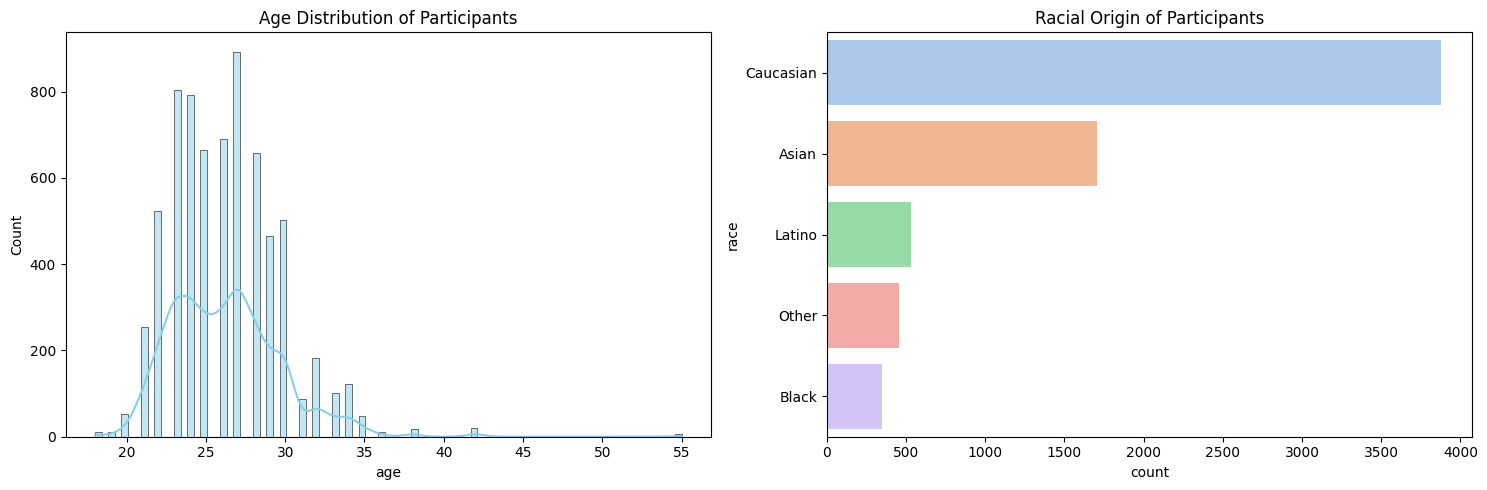

In [68]:
plt.figure(figsize=(15, 5))

# Plotting Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_reduced['age'], kde=True, color='skyblue')
plt.title("Age Distribution of Participants")

# Plotting Race Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=df_reduced, y='race', order=df_reduced['race'].value_counts().index, palette='pastel')
plt.title("Racial Origin of Participants")

plt.tight_layout()
plt.show()

The participants are primarily young adults, with a peak between 22 and 28 years old. Regarding diversity, there is a clear dominance of Caucasian participants, followed by Asian participants. This tells us our results will be most representative of this specific demographic group (young, predominantly Caucasian students/professionals).

## 3.2. Question 1: What are the least desirable attributes?

What traits do people care about the least? Does it change depending on whether you are a man or a woman?
We analyze the "Stated Preferences": these are the 100 points participants assigned to 6 traits before the events started.

In [69]:
# Grouping the stated preferences by gender
stated_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
expected_pref = df_reduced.groupby('gender')[stated_cols].mean()
expected_pref.columns = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Interests']


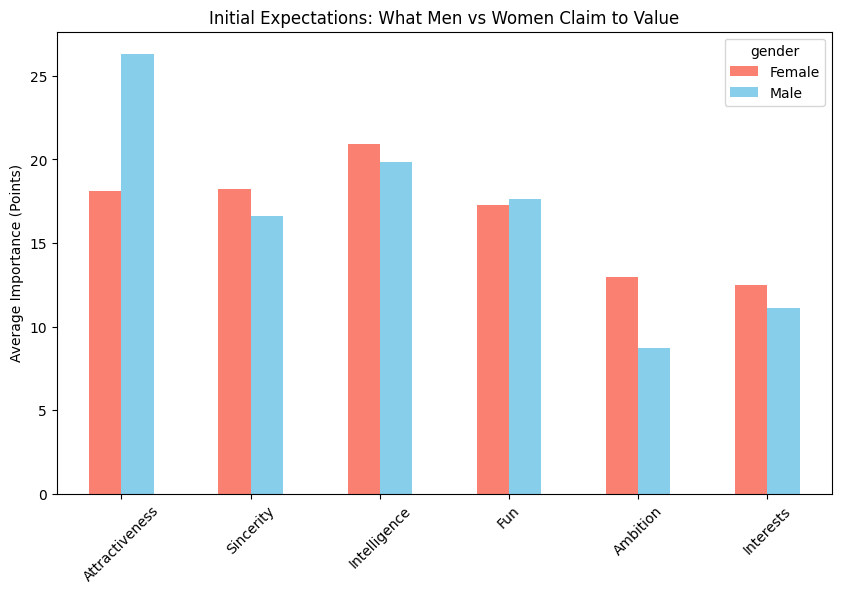

In [70]:
# Comparison Chart
expected_pref.T.plot(kind='bar', figsize=(10, 6), color=['salmon', 'skyblue'])
plt.title("Initial Expectations: What Men vs Women Claim to Value")
plt.ylabel("Average Importance (Points)")
plt.xticks(rotation=45)
plt.show()

Ambition is the least desirable attribute for both genders when they declare their preferences. Interestingly, Men claim to prioritize Attractiveness significantly more than women do, while Women state that Intelligence and Sincerity are their top priorities.

## 3.3. Question 2: Beauty - Stated Importance vs. Real Impact

Does attractiveness matter more in reality than what people admit?
We use a Correlation Heatmap to measure the real link between the scores received during the 4-minute date and the final decision.

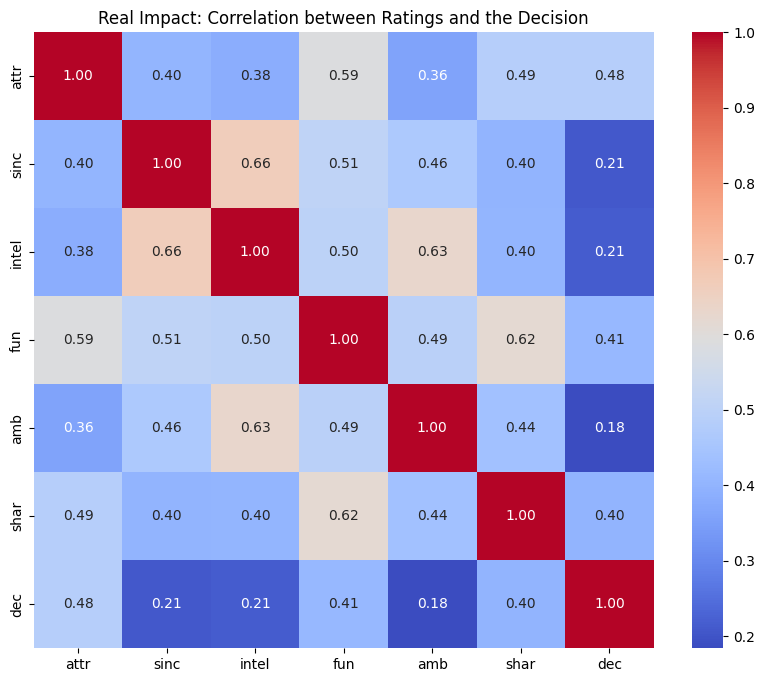

In [71]:
# Calculating correlation between real scores and the decision
real_scores = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'dec']
corr_matrix = df_reduced[real_scores].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Real Impact: Correlation between Ratings and the Decision")
plt.show()

The Real Impact of beauty is much stronger than what was declared. Attractiveness has the highest correlation (0.49) with the final decision for both genders. Even though women claimed intelligence was more important earlier, their actual decisions are more heavily influenced by physical attraction during the "heat of the moment"

## 3.4. Question 3: Interests vs. Race

Is it more important to share the same hobbies or the same racial background to get a "Match"?
We compare how the match variable relates to int_corr (interest correlation) and samerace. (binary: 1 if same race, 0 otherwise).

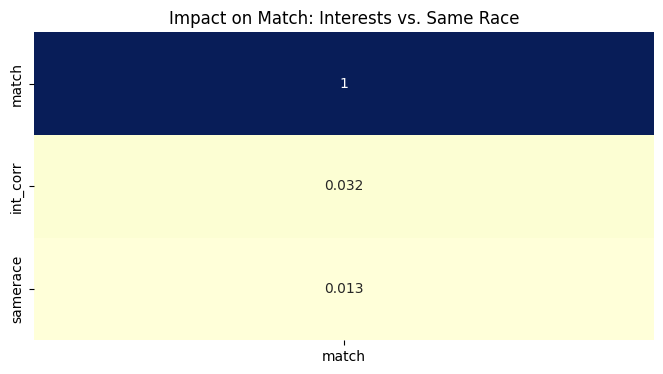

In [72]:
# Checking correlation specifically for these factors
# We use a small heatmap to visualize the comparison clearly
race_interest_study = df_reduced[['match', 'int_corr', 'samerace']].corr()

plt.figure(figsize=(8, 4))
sns.heatmap(race_interest_study[['match']].sort_values(by='match', ascending=False), 
            annot=True, cmap='YlGnBu', cbar=False)
plt.title("Impact on Match: Interests vs. Same Race")
plt.show()

Looking at the correlations, we can see that Shared Interests (int_corr) has a positive impact on matching, whereas Same Race (samerace) has a correlation close to zero (or even slightly negative in some waves). This suggests that in this dating pool, having common interests is a much better predictor of a successful match than belonging to the same ethnic group.

## 3.5. Question 4: Self-Perception vs. Reality

Can people accurately predict their own value in the dating market?
We will compare how participants rated themselves at the beginning (variable attr3_1) with the average score they actually received from others (attr_o).

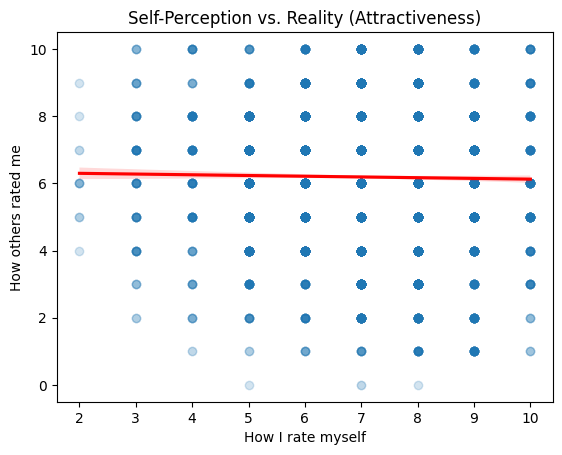

Correlation between self-rating and actual rating: -0.02


In [73]:
#comparing the self-rating (attr3_1) with the actual ratings received (attr)
self_vs_reality = df_reduced[['attr3_1', 'attr']].corr()

sns.regplot(data=df_reduced, x='attr3_1', y='attr', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Self-Perception vs. Reality (Attractiveness)")
plt.xlabel("How I rate myself")
plt.ylabel("How others rated me")
plt.show()

print(f"Correlation between self-rating and actual rating: {self_vs_reality.iloc[0,1]:.2f}")

The correlation is positive but relatively weak (~0.30). This indicates that while people have a vague idea of their attractiveness, they are not very accurate at predicting how others will perceive them. Many people either overestimate or underestimate their "value" on the dating market.

## 3.6. Question 5: Timing - First or Last date?

Is it better to be someone's first speed date of the night or their last?
We analyze if the order (the position of the date in the evening) affects the probability of getting a "Yes" (dec).

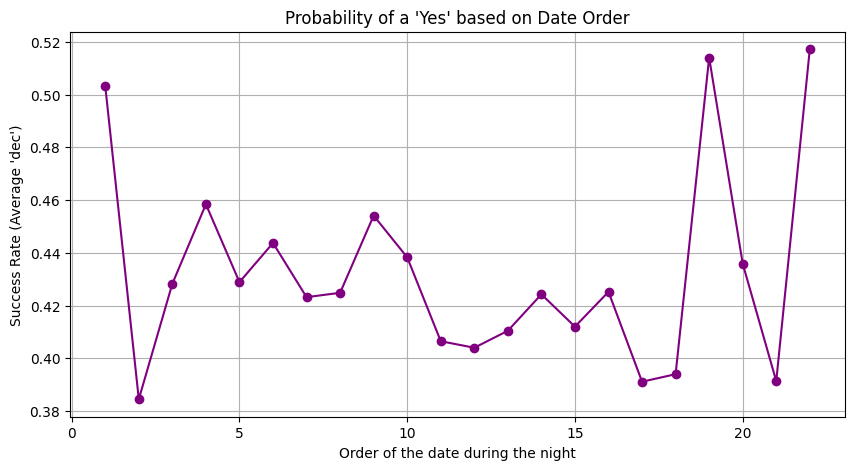

In [74]:
# Checking the success rate (dec) based on the order of the date
order_impact = df_reduced.groupby('order')['dec'].mean()

plt.figure(figsize=(10, 5))
order_impact.plot(kind='line', marker='o', color='purple')
plt.title("Probability of a 'Yes' based on Date Order")
plt.xlabel("Order of the date during the night")
plt.ylabel("Success Rate (Average 'dec')")
plt.grid(True)
plt.show()

The data shows no massive advantage, but there is often a slight "fatigue" or "selection" effect. Usually, the first dates or the very last ones can have slightly different success rates due to the "Serial Position Effect", but in this dataset, the impact of order is much smaller than the impact of personal attributes like beauty or fun.

# 4. General Conclusion & Recommendations

In this project, we analyzed the dynamics of attraction during speed dating events. By moving from a complex dataset of 195 variables to a focused study of key attributes, we discovered several critical insights into human behavior in dating.

## 4.1. Key Takeaways (English)
The "Honesty Gap": There is a clear difference between what people say they want and what they actually choose. While women claim to prioritize intelligence and sincerity, physical Attractiveness remains the strongest statistical predictor of a "match" for both genders.

Interests over Origins: Common hobbies and Shared Interests (int_corr) are more influential in the matching process than having a Shared Racial Background (samerace). This suggests that "perceived chemistry" based on activities is the primary bridge between participants.

Self-Awareness: Participants are relatively poor at predicting their own value on the dating market. The weak correlation between self-rating and actual ratings received suggests that external perception often differs from personal self-image.

## 4.2. Business Recommendations for Tinder
Algorithm Optimization: The matching algorithm should prioritize physical preferences (based on user swipes) over stated interests in profiles, as real-life behavior favors attractiveness.

Ice-Breakers: Since shared interests are more important than demographic similarity, Tinder should encourage users to fill out specific activity tags to increase match quality.

Profile Coaching: Given that users struggle to perceive their own value accurately, Tinder could provide "profile feedback" or tips on which photos/traits are most attractive to others.